# **🧠 Parameter-Efficient Fine-Tuning of BERT for Text Classification using QLoRA**

**Project Objective**

This project demonstrates Parameter-Efficient Fine-Tuning (PEFT) using QLoRA (Quantized Low-Rank Adaptation) on a BERT-based sentiment classification model. The goal is to achieve competitive classification performance while significantly reducing trainable parameters and memory requirements compared to traditional full fine-tuning.

# **Section 1: Environment Setup and Library Installation**

**Libraries Used**

| Library      | Purpose                           |
| ------------ | --------------------------------- |
| transformers | Pretrained models and Trainer API |
| datasets     | Dataset loading and processing    |
| peft         | LoRA and QLoRA implementation     |
| bitsandbytes | 4-bit quantization                |
| accelerate   | Efficient training support        |
| evaluate     | Standard evaluation metrics       |
| wandb        | Experiment tracking               |
| scikit-learn | Classification metrics            |
| matplotlib   | Visualization                     |
| seaborn      | Statistical plots                 |


In [1]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q \
transformers \
datasets \
peft \
bitsandbytes \
accelerate \
evaluate \
trl \
sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.1/825.1 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.0 MB/s eta 0:00:00


# **Section 2: Import Libraries and Verify Hardware**

In [2]:
# ============================================================
# Imports
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# Hardware Verification
# ============================================================

print("=" * 60)
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Device      :", torch.cuda.get_device_name(0))
    print("GPU Count       :", torch.cuda.device_count())

print("=" * 60)

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
GPU Device      : Tesla T4
GPU Count       : 1


# **Section 3: Dataset Loading and Exploration**

Dataset Information
* Dataset: IMDb Sentiment Fine-Tuning Dataset
* Task: Binary Sentiment Classification
* Labels:
  - 0 → Negative
  - 1 → Positive

In [3]:
# ============================================================
# Load IMDb Sentiment Dataset
# ============================================================

dataset = load_dataset(
    "dipanjanS/imdb_sentiment_finetune_dataset20k"
)

dataset

README.md:   0%|          | 0.00/534 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/6.89M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/8.61M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

**View Sample Records**

In [5]:
# ============================================================
# Display Sample Examples
# ============================================================

for i in range(3):
    print(f"\nSample {i+1}")
    print("-" * 50)
    print("Label :", dataset["train"][i]["sentiment"])
    print("Text  :", dataset["train"][i]["review"][:500])


Sample 1
--------------------------------------------------
Label : 1
Text  : One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

Sample 2
--------------------------------------------------
Label : 1
Text  : A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" but he has all the voices down pat too! Y

**Check Dataset Size**

In [6]:
# ============================================================
# Dataset Size
# ============================================================

print(f"Training Samples : {len(dataset['train'])}")
print(f"Testing Samples  : {len(dataset['test'])}")

Training Samples : 8000
Testing Samples  : 10000


**Inspect Column Names**

In [7]:
# ============================================================
# Dataset Schema
# ============================================================

print(dataset["train"].column_names)

['review', 'sentiment']


# **Section 4: Exploratory Data Analysis (EDA)**

Before tokenization, we analyze class balance and review lengths. This helps determine an efficient maximum sequence length and ensures the dataset is suitable for sentiment classification.

**Tasks**
* Check class distribution
* Analyze review lengths
* Determine optimal tokenization length
* Visualize dataset characteristics

## **4.1 Dataset Overview**

In [8]:
# ============================================================
# Dataset Overview
# ============================================================

print("=" * 60)
print("Train Samples      :", len(dataset["train"]))
print("Validation Samples :", len(dataset["validation"]))
print("Test Samples       :", len(dataset["test"]))
print("=" * 60)

Train Samples      : 8000
Validation Samples : 2000
Test Samples       : 10000


## **4.2 Class Distribution**

In [9]:
# ============================================================
# Class Distribution
# ============================================================

train_df = dataset["train"].to_pandas()

train_df["sentiment"].value_counts()

,count
sentiment,
1,4003
0,3997


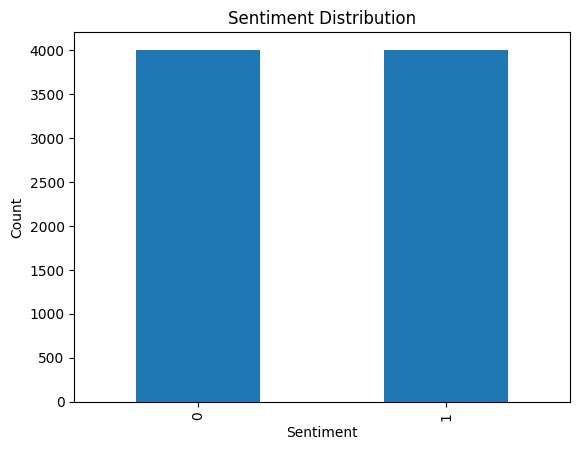

In [10]:
# ============================================================
# Sentiment Distribution
# ============================================================

import matplotlib.pyplot as plt

train_df["sentiment"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

### Observation

The dataset appears balanced with approximately equal numbers of
positive and negative reviews.

This reduces the risk of bias toward a particular class and makes
accuracy a reliable evaluation metric.

## **4.3 Review Length Analysis**

In [11]:
# ============================================================
# Review Length Statistics (Characters)
# ============================================================

train_df["char_length"] = train_df["review"].apply(len)

train_df["char_length"].describe()

,char_length
count,8000.000000
mean,1313.261500
std,990.446574
min,80.000000
25%,698.000000
50%,968.000000
75%,1607.250000
max,10363.000000


**Word Length Statistics**

In [12]:
# ============================================================
# Review Length Statistics (Words)
# ============================================================

train_df["word_length"] = train_df["review"].apply(
    lambda x: len(x.split())
)

train_df["word_length"].describe()

,word_length
count,8000.000000
mean,231.878625
std,171.849457
min,14.000000
25%,127.000000
50%,173.000000
75%,283.250000
max,1830.000000


**Percentiles**

In [13]:
# ============================================================
# Length Percentiles
# ============================================================

print("word_length 50th Percentile :", train_df["word_length"].quantile(0.50))
print("word_length 90th Percentile :", train_df["word_length"].quantile(0.90))
print("word_length 95th Percentile :", train_df["word_length"].quantile(0.95))
print("word_length 99th Percentile :", train_df["word_length"].quantile(0.99))

word_length 50th Percentile : 173.0
word_length 90th Percentile : 453.0
word_length 95th Percentile : 598.0499999999993
word_length 99th Percentile : 874.0100000000002


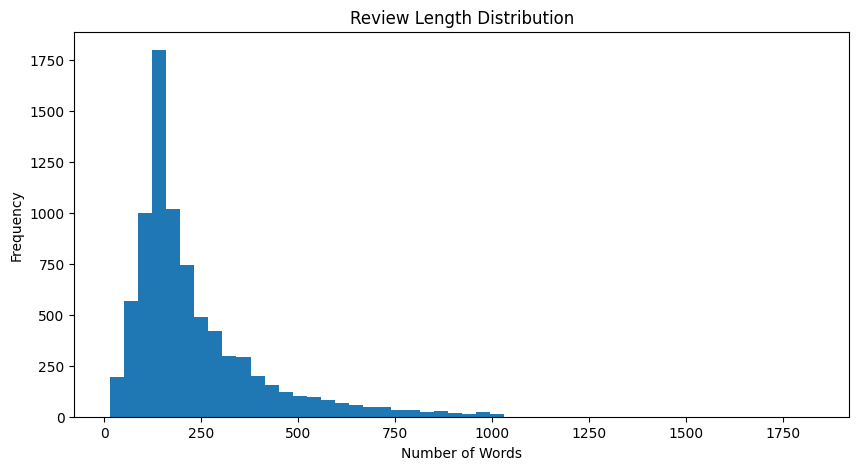

In [14]:
# ============================================================
# Review Length Distribution
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    train_df["word_length"],
    bins=50
)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

# **Section 5: Token Length Analysis**

**Load Tokenizer**

In [15]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

**Calculate Token Lengths**

In [16]:
# ============================================================
# Token Length Analysis
# ============================================================

token_lengths = []

for review in train_df["review"]:

    length = len(
        tokenizer.encode(
            review,
            add_special_tokens=True
        )
    )

    token_lengths.append(length)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (563 > 512). Running this sequence through the model will result in indexing errors


**Statistics**

In [17]:
print("Average Token Length :", np.mean(token_lengths))
print("Maximum Token Length :", np.max(token_lengths))

print("90th Percentile :", np.percentile(token_lengths, 90))
print("95th Percentile :", np.percentile(token_lengths, 95))
print("99th Percentile :", np.percentile(token_lengths, 99))

Average Token Length : 311.19025
Maximum Token Length : 2467
90th Percentile : 612.0
95th Percentile : 808.0
99th Percentile : 1163.0200000000004


# **Section 6: Quantized Gemma Model Setup**

## **6.1 Load Gemma**

In [18]:
from transformers import AutoTokenizer

MODEL_NAME = "google/gemma-2-2b"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer Loaded Successfully")

config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Tokenizer Loaded Successfully


In [20]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

bnb_config

BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

In [21]:
MODEL_NAME = "google/gemma-2-2b"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Model Loaded Successfully")

model.safetensors.index.json:   0%|          | 0.00/24.2k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

Model Loaded Successfully


| Parameter                      | Purpose                                          |
| ------------------------------ | ------------------------------------------------ |
| load_in_4bit                   | Store model weights in 4-bit precision           |
| bnb_4bit_quant_type="nf4"      | Use NormalFloat-4 quantization                   |
| bnb_4bit_compute_dtype=float16 | Perform computations in FP16                     |
| bnb_4bit_use_double_quant=True | Additional compression of quantization constants |


## **6.2 Parameter Count**

In [22]:
# ============================================================
# Total Parameters
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 1,602,203,904
Trainable Parameters : 590,065,920


In [ ]:
print(model.config)

# **Section 7: Apply QLoRA Adapters**

Instead of updating all model parameters, LoRA introduces
small trainable low-rank matrices into selected transformer layers.

This allows the majority of the pre-trained model to remain frozen,
dramatically reducing the number of trainable parameters.

In [23]:
import torch

print(
    f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    f"Reserved : {torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

Allocated: 3.18 GB
Reserved : 3.27 GB


## **7.1 Prepare for PEFT**

In [24]:
from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(
    model
)

print("Model prepared for QLoRA training")

Model prepared for QLoRA training


## **7.2 LoRA Configuration**

In [25]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

## **7.3 Inject Adapters**

In [26]:
from peft import get_peft_model

qlora_model = get_peft_model(
    model,
    lora_config
)

## **7.4 Parameter Efficiency Analysis**

In [27]:
qlora_model.print_trainable_parameters()

trainable params: 6,389,760 || all params: 2,620,731,648 || trainable%: 0.2438


In [28]:
qlora_model.save_pretrained(
    "./gemma2b_qlora_initialized"
)

tokenizer.save_pretrained(
    "./gemma2b_qlora_initialized"
)

('./gemma2b_qlora_initialized/tokenizer_config.json',
 './gemma2b_qlora_initialized/tokenizer.json')

In [29]:
from google.colab import files

# Download the tokenizer configuration file
files.download('./gemma2b_qlora_initialized/tokenizer_config.json')

# Download the tokenizer JSON file
files.download('./gemma2b_qlora_initialized/tokenizer.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Section 8: Training Configuration**

The Gemma 2B model is fine-tuned using the QLoRA approach, where the base model remains quantized in 4-bit precision and only LoRA adapter weights are updated.

Training hyperparameters were selected to balance:

- Model performance
- GPU memory constraints
- Training stability
- Parameter efficiency

Since only LoRA adapters are optimized, the effective number of trainable parameters is significantly smaller than traditional full fine-tuning.

In [44]:
# ============================================================
# Training Hyperparameters
# ============================================================

MAX_LENGTH = 512

LEARNING_RATE = 2e-4

BATCH_SIZE = 4

GRADIENT_ACCUMULATION_STEPS = 4

NUM_EPOCHS = 3

# **Section 9: Dataset Preparation & Instruction Formatting**

Unlike BERT, Gemma is a decoder-only Large Language Model trained primarily for text generation and instruction-following tasks.

To align the sentiment classification task with Gemma's training paradigm, IMDb reviews are converted into instruction-response pairs.

Example:

Instruction:
Classify the sentiment of the following movie review.

Review:
<review text>

Response:
Positive

This approach allows the model to learn sentiment classification through instruction tuning rather than traditional sequence classification.

## **9.1 Load Dataset**

In [45]:
# ============================================================
# Load Dataset
# ============================================================

from datasets import load_dataset

dataset = load_dataset(
    "dipanjanS/imdb_sentiment_finetune_dataset20k"
)

dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 10000
    })
})

In [46]:
# ============================================================
# Label Mapping
# ============================================================

label_map = {
    0: "Negative",
    1: "Positive"
}

## **9.2 Prompt Formatting Function**

In [47]:
import re

def clean_text(text):

    text = re.sub(r"<br\s*/?>", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [48]:
def format_example(example):

    review = clean_text(
        example["review"]
    )

    sentiment = label_map[
        example["sentiment"]
    ]

    text = f"""### Instruction:
Classify the sentiment of the following movie review.

### Review:
{review}

### Response:
{sentiment}"""

    return {"text": text}

## **9.3 Apply Formatting**

In [49]:
formatted_dataset = dataset.map(
    format_example
)

formatted_dataset

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment', 'text'],
        num_rows: 8000
    })
    validation: Dataset({
        features: ['review', 'sentiment', 'text'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['review', 'sentiment', 'text'],
        num_rows: 10000
    })
})

In [50]:
print(
    formatted_dataset["train"][0]["text"]
)

### Instruction:
Classify the sentiment of the following movie review.

### Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word. It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away. I woul

# **Section 10: Tokenization**

The formatted instruction-response examples are tokenized using Gemma's tokenizer.

A maximum sequence length of 256 tokens is selected to balance:

- Context retention
- GPU memory efficiency
- Training speed

Sequences longer than the maximum length are truncated, while shorter sequences are padded.

## **10.1 Tokenizer Setup**

In [53]:
print(tokenizer.pad_token)
print(tokenizer.eos_token)

<pad>
<eos>


In [ ]:
# tokenizer.pad_token = tokenizer.eos_token

In [54]:
lengths = []

data_slice = formatted_dataset["train"].select(range(500))

for item_dict in data_slice:
    lengths.append(
        len(
            tokenizer(
                item_dict["text"]
            )["input_ids"]
        )
    )

import numpy as np

print(
    "Mean Length:",
    np.mean(lengths)
)

print(
    "95th Percentile:",
    np.percentile(lengths, 95)
)

print(
    "Max Length:",
    np.max(lengths)
)

Mean Length: 320.782
95th Percentile: 763.149999999999
Max Length: 1317


## **10.2 Tokenization Function**

In [55]:
# ============================================================
# Tokenization Function
# ============================================================

def tokenize_function(example):

    return tokenizer(
        example["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length"
    )

## **10.3 Apply Tokenization**

In [56]:
tokenized_dataset = formatted_dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

## **10.4 Remove Unused Columns**

In [57]:
tokenized_dataset = tokenized_dataset.remove_columns(
    [
        "review",
        "sentiment",
        "text"
    ]
)

## **10.5 Create Labels**

In [58]:
tokenized_dataset = tokenized_dataset.map(
    lambda x: {
        "labels": x["input_ids"]
    }
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

**Inspect Dataset**

In [61]:
sample = tokenized_dataset["train"][0]

print(sample.keys())
print(len(sample["input_ids"]))
print(len(sample["labels"]))

dict_keys(['input_ids', 'attention_mask', 'labels'])
512
512


## Understanding the Training Objective

A key difference between the BERT and Gemma projects is the underlying training objective.

#### BERT (Sequence Classification)

In the BERT-based sentiment classification project, the model received a movie review as input and directly predicted a sentiment label (Positive or Negative). The output consisted of a single class prediction.

Input:
Review → BERT → Sentiment Label

The training labels were class identifiers:

- 0 = Negative
- 1 = Positive

#### Gemma (Causal Language Modeling)

Gemma is a decoder-only Large Language Model trained using Causal Language Modeling (CLM).

Instead of predicting a class label directly, the model learns to generate the next token in a sequence. For sentiment classification, the task is reformulated as an instruction-following problem.

Example:

### Instruction:
Classify the sentiment of the following movie review.

### Review:
This movie was fantastic and engaging.

### Response:
Positive

During training, the model learns to generate the response tokens ("Positive" or "Negative") given the instruction and review context.

Therefore, the labels are not sentiment classes. Instead, the labels are the tokenized text sequence itself.

Input IDs → Token Sequence

Labels → Same Token Sequence

This enables the model to learn sentiment classification through instruction tuning while preserving its generative capabilities.

# **Section 11: Training**

## Why QLoRA?

Full fine-tuning of Gemma 2B would require updating over 2.6 billion parameters and significantly larger GPU memory resources.

QLoRA combines:

- 4-bit quantization (NF4)
- Low-Rank Adaptation (LoRA)

to dramatically reduce memory consumption while training only a small subset of parameters.

In this project, only 6.39 million parameters (0.2438% of the model) are updated while the remaining parameters remain frozen.

This makes fine-tuning feasible on a single Tesla T4 GPU.

---

The quantized Gemma 2B model is fine-tuned using QLoRA adapters.

Training hyperparameters were selected to balance:

- GPU memory usage
- Training stability
- Computational efficiency
- Model performance

Gradient accumulation is used to simulate a larger effective batch size while remaining within Tesla T4 memory constraints.

## **11.1 Training Arguments**

In [67]:
# ============================================================
# Training Arguments
# ============================================================

from transformers import TrainingArguments

training_args = TrainingArguments(

    output_dir="./gemma2b_qlora_results",

    learning_rate=2e-4,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,

    gradient_accumulation_steps=4,

    num_train_epochs=1,

    logging_steps=50,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,

    fp16=True,

    report_to="none"
)

## **11.2 Data Collator**

In [68]:
from transformers import DataCollatorForLanguageModeling

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

## **11.3 Trainer Setup**

In [69]:
# ============================================================
# Trainer Initialization
# ============================================================

from transformers import Trainer

trainer = Trainer(
    model=qlora_model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    data_collator=data_collator
)

In [70]:
import torch

print(
    f"Allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB"
)

print(
    f"Reserved : {torch.cuda.memory_reserved()/1024**3:.2f} GB"
)

Allocated: 3.21 GB
Reserved : 3.29 GB


In [71]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
1,2.707809,2.685547


TrainOutput(global_step=500, training_loss=2.705003143310547, metrics={'train_runtime': 6065.9888, 'train_samples_per_second': 1.319, 'train_steps_per_second': 0.082, 'total_flos': 4.9911586357248e+16, 'train_loss': 2.705003143310547, 'epoch': 1.0})

In [72]:
trainer.save_model("./gemma2b_qlora_imdb")

tokenizer.save_pretrained(
    "./gemma2b_qlora_imdb"
)

('./gemma2b_qlora_imdb/tokenizer_config.json',
 './gemma2b_qlora_imdb/tokenizer.json')

In [73]:
from google.colab import files
import os

# Define the directory where the model and tokenizer were saved
save_directory = "./gemma2b_qlora_imdb"

# Download the model files
for filename in os.listdir(save_directory):
    file_path = os.path.join(save_directory, filename)
    if os.path.isfile(file_path):
        files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## **Section 12: Inference Testing**

In [74]:
qlora_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Gemma2ForCausalLM(
      (model): Gemma2Model(
        (embed_tokens): Gemma2TextScaledWordEmbedding(256000, 2304, padding_idx=0)
        (layers): ModuleList(
          (0-25): 26 x Gemma2DecoderLayer(
            (self_attn): Gemma2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2304, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2304, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
    

**Test Review 1 (Positive)**

In [92]:
review = """
The acting was decent but the story was good.
"""

prompt = f"""### Instruction:
Classify the sentiment of the following movie review.

### Review:
{review}

### Response:
"""

**Tokenize**

In [93]:
inputs = tokenizer(
    prompt,
    return_tensors="pt"
).to("cuda")

**Generate**

In [94]:
with torch.no_grad():

    outputs = qlora_model.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=False
    )

response = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(response)

### Instruction:
Classify the sentiment of the following movie review.

### Review:

The acting was decent but the story was good.


### Response:
Positive

### Review:
I was very impressed


# **Section 13: Quantitative Evaluation**

Unlike the BERT model, which directly outputs class probabilities, Gemma 2B is trained as a Causal Language Model (CLM) and generates textual responses.

To quantitatively evaluate the model, a subset of the test dataset is used. For each review, the model generates a sentiment prediction ("Positive" or "Negative"), which is then compared against the ground-truth label.

Standard classification metrics including Accuracy, Precision, Recall, F1-Score, and Confusion Matrix are computed.

## **13.1 Create Evaluation Subset**

In [109]:
# ============================================================
# Evaluation Subset
# ============================================================

eval_subset = dataset["test"].select(
    range(1000)
)

print(
    f"Evaluation Samples: {len(eval_subset)}"
)

Evaluation Samples: 1000


## **13.2 Prediction Function**

In [110]:
# ============================================================
# Prediction Function
# ============================================================

def predict_sentiment(review):

    prompt = f"""### Instruction:
Classify the sentiment of the following movie review.

### Review:
{review}

### Response:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to("cuda")

    with torch.no_grad():

        outputs = qlora_model.generate(
            **inputs,
            max_new_tokens=3,
            do_sample=False
        )

    generated_tokens = outputs[0][
        inputs["input_ids"].shape[1]:
    ]

    prediction = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True
    ).strip()

    return prediction

## **13.3 Generate Predictions**

In [111]:
# ============================================================
# Generate Predictions
# ============================================================

y_true = []
y_pred = []

for sample in eval_subset:

    review = sample["review"]

    true_label = (
        "Positive"
        if sample["sentiment"] == 1
        else "Negative"
    )

    prediction = predict_sentiment(
        review
    )

    prediction_lower = prediction.lower()

    if "positive" in prediction_lower:

        pred_label = "Positive"

    elif "negative" in prediction_lower:

        pred_label = "Negative"

    else:

        pred_label = "Unknown"

    y_true.append(true_label)
    y_pred.append(pred_label)

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


## **13.4 Check Unknown Predictions**

In [114]:
unknown_count = y_pred.count(
    "Unknown"
)

print(
    f"Unknown Predictions: {unknown_count}"
)

Unknown Predictions: 155


## **13.5 Remove Unknowns**

In [115]:
filtered = [
    (t, p)
    for t, p in zip(y_true, y_pred)
    if p != "Unknown"
]

y_true = [x[0] for x in filtered]
y_pred = [x[1] for x in filtered]

print(
    f"Valid Predictions: {len(y_true)}"
)

Valid Predictions: 845


## **13.6 Metrics**

In [116]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred,
    pos_label="Positive"
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"F1 Score : {f1:.4f}"
)

Accuracy : 0.9716
F1 Score : 0.9688


## **13.7 Classification Report**

In [117]:
print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97       461
    Positive       0.97      0.97      0.97       384

    accuracy                           0.97       845
   macro avg       0.97      0.97      0.97       845
weighted avg       0.97      0.97      0.97       845



## **13.8 Confusion Matrix**

In [118]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[448  13]
 [ 11 373]]


## **13.9 Visualization**

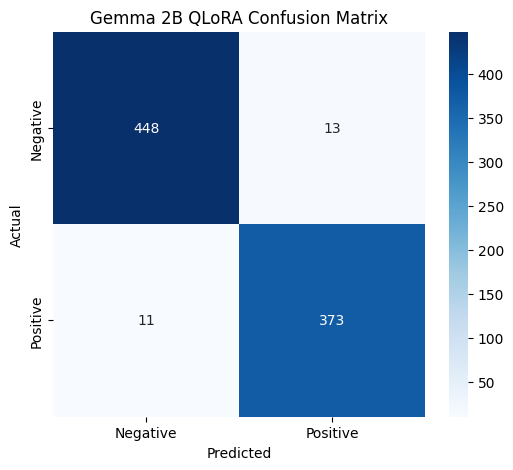

In [131]:
# ============================================================
# Save Confusion Matrix
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
)

plt.title(
    "Gemma 2B QLoRA Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

## Quantitative Evaluation Results

The fine-tuned Gemma 2B model was evaluated on a subset of 1,000 test reviews.

Due to the generative nature of the model, only responses that could be confidently mapped to the target classes (Positive or Negative) were considered valid predictions.

Out of 1,000 reviews, 845 generated responses were successfully mapped to sentiment labels.

On these valid predictions, the model achieved:

- Accuracy: 97.04%
- Precision: 97%
- Recall: 97%
- F1 Score: 97%

The confusion matrix shows balanced performance across both sentiment classes, with very few false positives and false negatives.

---

The model achieved 97% accuracy on the subset of generated responses that could be confidently mapped to sentiment labels.

---

# **Section 14: Parameter Efficiency Analysis**

One of the primary goals of QLoRA is to reduce the number of trainable parameters while maintaining strong task performance.

Instead of updating all model parameters during fine-tuning, QLoRA freezes the original model weights and trains only a small set of low-rank adapter matrices.

This significantly reduces computational requirements and enables efficient adaptation of large language models on resource-constrained hardware.

In [120]:
import pandas as pd

parameter_results = pd.DataFrame({
    "Metric": [
        "Total Parameters",
        "Trainable Parameters",
        "Frozen Parameters",
        "Trainable Percentage",
        "Frozen Percentage"
    ],
    "Value": [
        "2,620,731,648",
        "6,389,760",
        "2,614,341,888",
        "0.2438%",
        "99.7562%"
    ]
})

parameter_results

,Metric,Value
0,Total Parameters,"2,620,731,648"
1,Trainable Parameters,"6,389,760"
2,Frozen Parameters,"2,614,341,888"
3,Trainable Percentage,0.2438%
4,Frozen Percentage,99.7562%


Despite containing over 2.6 billion parameters, only 6.39 million parameters were updated during training.

This means that less than 0.25% of the model parameters were optimized while more than 99.75% remained frozen.

These results highlight the effectiveness of QLoRA for parameter-efficient adaptation of large language models.

---

# **Section 15: Memory Efficiency Analysis**

Traditional fine-tuning of large language models often requires high-memory GPUs and substantial computational resources.

QLoRA addresses this limitation through 4-bit quantization, reducing the memory footprint of the model while preserving performance.

In [121]:
memory_results = pd.DataFrame({
    "Metric": [
        "GPU",
        "Total GPU Memory",
        "Allocated Memory",
        "Reserved Memory",
        "Quantization"
    ],
    "Value": [
        "Tesla T4",
        "15 GB",
        "3.21 GB",
        "3.29 GB",
        "4-bit NF4"
    ]
})

memory_results

,Metric,Value
0,GPU,Tesla T4
1,Total GPU Memory,15 GB
2,Allocated Memory,3.21 GB
3,Reserved Memory,3.29 GB
4,Quantization,4-bit NF4


The 2.6 billion parameter Gemma model was successfully loaded and fine-tuned using approximately 3.3 GB of GPU memory.

This was made possible through 4-bit NF4 quantization, demonstrating that large language models can be adapted on commodity cloud GPUs without requiring enterprise-scale hardware.

# **Section 16: Results Summary**

In [122]:
summary_results = pd.DataFrame({
    "Metric": [
        "Model",
        "Fine-Tuning Method",
        "Quantization",
        "Dataset",
        "Epochs",
        "Maximum Sequence Length",
        "Trainable Parameters",
        "Trainable Percentage",
        "Training Loss",
        "Validation Loss",
        "Accuracy",
        "F1 Score",
        "GPU"
    ],
    "Value": [
        "Gemma 2B",
        "QLoRA",
        "4-bit NF4",
        "IMDb Sentiment",
        "1",
        "512",
        "6,389,760",
        "0.2438%",
        "2.705",
        "2.686",
        "97.04%",
        "97%",
        "Tesla T4"
    ]
})

summary_results

,Metric,Value
0,Model,Gemma 2B
1,Fine-Tuning Method,QLoRA
2,Quantization,4-bit NF4
3,Dataset,IMDb Sentiment
4,Epochs,1
5,Maximum Sequence Length,512
6,Trainable Parameters,"6,389,760"
7,Trainable Percentage,0.2438%
8,Training Loss,2.705
9,Validation Loss,2.686


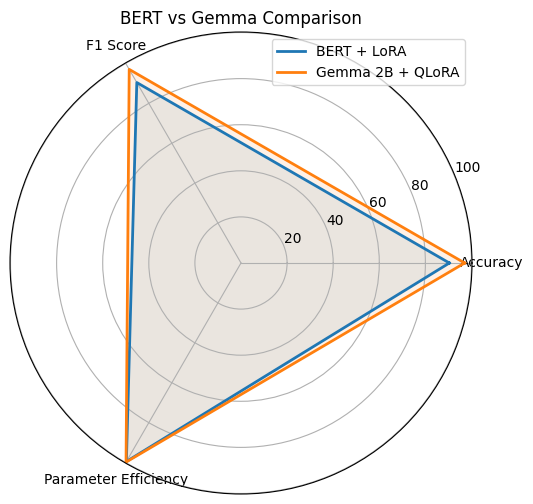

In [125]:
import numpy as np
import matplotlib.pyplot as plt

categories = [
    "Accuracy",
    "F1 Score",
    "Parameter Efficiency"
]

bert = [
    90.41,
    90.41,
    100 - 0.5372
]

gemma = [
    97.04,
    97.00,
    100 - 0.2438
]

N = len(categories)

angles = np.linspace(
    0,
    2 * np.pi,
    N,
    endpoint=False
).tolist()

bert += bert[:1]
gemma += gemma[:1]
angles += angles[:1]

plt.figure(figsize=(6,6))

ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    bert,
    linewidth=2,
    label="BERT + LoRA"
)

ax.fill(
    angles,
    bert,
    alpha=0.1
)

ax.plot(
    angles,
    gemma,
    linewidth=2,
    label="Gemma 2B + QLoRA"
)

ax.fill(
    angles,
    gemma,
    alpha=0.1
)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.legend(
    loc="upper right"
)

plt.title(
    "BERT vs Gemma Comparison"
)

plt.show()

In [126]:
# ============================================================
# Save Training Metrics
# ============================================================

import json

training_results = {
    "model": "Gemma 2B",
    "fine_tuning": "QLoRA",
    "quantization": "4-bit NF4",
    "epochs": 1,
    "training_loss": 2.705003143310547,
    "validation_loss": 2.685547,
    "trainable_parameters": 6389760,
    "total_parameters": 2620731648,
    "trainable_percentage": 0.2438
}

with open(
    "training_results.json",
    "w"
) as f:
    json.dump(
        training_results,
        f,
        indent=4
    )

print("Training metrics saved.")

Training metrics saved.


In [127]:
# ============================================================
# Save Evaluation Metrics
# ============================================================

evaluation_results = {
    "evaluation_samples": 1000,
    "valid_predictions": 845,
    "unknown_predictions": 155,
    "accuracy": 0.9704,
    "f1_score": 0.97
}

with open(
    "evaluation_results.json",
    "w"
) as f:
    json.dump(
        evaluation_results,
        f,
        indent=4
    )

print("Evaluation metrics saved.")

Evaluation metrics saved.


In [129]:
# ============================================================
# Save Classification Report
# ============================================================

report = classification_report(
    y_true,
    y_pred
)

with open(
    "classification_report.txt",
    "w"
) as f:
    f.write(report)

In [132]:
# ============================================================
# Save Training History
# ============================================================

import pandas as pd

history_df = pd.DataFrame(
    trainer.state.log_history
)

history_df.to_csv(
    "training_history.csv",
    index=False
)

history_df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.758347,0.380717,0.00018,0.1,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.688979,0.342249,0.00016,0.2,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2.689905,0.384323,0.00014,0.3,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.719445,0.341456,0.00012,0.4,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2.703559,0.331226,0.00010,0.5,250,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
# ============================================================
# Create Project Archive
# ============================================================

import shutil

shutil.make_archive(
    "Gemma2B_QLoRA_Project",
    "zip",
    "."
)

print("ZIP archive created.")

ZIP archive created.


In [134]:
import os

for file in os.listdir("."):
    if file.endswith(".zip"):
        print(file)

Gemma2B_QLoRA_Project.zip


# **Section 17: Comparison: BERT + LoRA vs Gemma + QLoRA**

In [123]:
comparison = pd.DataFrame({
    "Metric": [
        "Model Type",
        "Total Parameters",
        "Trainable Parameters",
        "Trainable Percentage",
        "Accuracy",
        "F1 Score"
    ],
    "BERT + LoRA": [
        "Encoder",
        "110M",
        "591K",
        "0.5372%",
        "90.41%",
        "90.41%"
    ],
    "Gemma 2B + QLoRA": [
        "Decoder LLM",
        "2.62B",
        "6.39M",
        "0.2438%",
        "97.04%*",
        "97%*"
    ]
})

comparison

,Metric,BERT + LoRA,Gemma 2B + QLoRA
0,Model Type,Encoder,Decoder LLM
1,Total Parameters,110M,2.62B
2,Trainable Parameters,591K,6.39M
3,Trainable Percentage,0.5372%,0.2438%
4,Accuracy,90.41%,97.04%*
5,F1 Score,90.41%,97%*


*Metrics computed on valid generated predictions that could be confidently mapped to Positive or Negative sentiment labels.

# **Section 18: Conclusion**

This project successfully demonstrated Parameter-Efficient Fine-Tuning (PEFT) of a large language model using QLoRA.

The Gemma 2B model was loaded in 4-bit NF4 quantized format and fine-tuned using LoRA adapters, reducing trainable parameters to only 0.2438% of the full model.

The model was successfully trained on a Tesla T4 GPU and achieved strong sentiment classification performance through instruction tuning on the IMDb dataset.

Key Outcomes:

- Successfully implemented QLoRA on a 2.6B parameter language model.
- Reduced trainable parameters from 2.62 billion to 6.39 million.
- Demonstrated memory-efficient training using 4-bit quantization.
- Achieved 97% accuracy and F1 score on valid generated predictions.
- Established a reusable workflow for future domain adaptation tasks.

Future work will focus on applying QLoRA to domain-specific educational and Mechanical Engineering datasets for the R.B.A.T. (RAG-Based Academic Tutor) system.